<a href="https://colab.research.google.com/github/kimheeseo/LSCNS/blob/main/paper/hcf-optimum-launch-power-reproduction/independent_hcf_5paper_validation_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# DNANF/HCF 독립 실험 논문 5편 교차검증

이 노트북은 기존 `dnanf_fig2_hcf_colab.ipynb`의 **보정된 Fig. 2 재현 결과가 아니라**, 보정에 사용하지 않은 실험 논문 5편에 현재 모델을 적용한 독립 교차검증입니다.

핵심 원칙:

- `calibrate_dispersion()`을 사용하지 않습니다.
- 0.075/0.120 dB/km 기준점으로 손실을 다시 맞추지 않습니다.
- 기존 코드의 고정값 `NF=5 dB`, `TRX SNR=20 dB`, `gamma=5e-4 1/(W km)`은 그대로 노출하여 독립 논문과 충돌하는지 확인합니다.
- 논문에 기하치수가 없으면 측정된 손실/분산/IMI를 입력하므로, 그 Case는 **기하 모델이 아니라 시스템 모델**만 검증합니다.
- 공개되지 않은 값은 fitting하지 않고 `ASSUMPTION`으로 표시합니다.
- 상한값 또는 정성적 결과에 MAPE를 억지로 적용하지 않습니다.

## 검증 논문과 데이터 출처

1. X. Chen et al., *Measurements of Group Delay and Chromatic Dispersion of Hollow-Core Fiber Using a Frequency Domain Method*, Photonics 12, 47 (2025).  
   https://www.mdpi.com/2304-6732/12/1/47
2. D. Ge et al., *Estimation of Kerr Nonlinearity in an Anti-resonant Hollow-Core Fiber by High-order QAM Transmission*, OFC 2023 W4D.6.  
   https://opg.optica.org/abstract.cfm?uri=OFC-2023-W4D.6
3. Y. Hong et al., *Demonstration of Beyond Terabit/s/lambda Nonlinearity-free Transmission over the Hollow-core Fibre* (2024; later JLT 2025).  
   https://arxiv.org/pdf/2409.00058
4. D. Ge et al., *1-Tb/s/lambda Transmission over Record 10714-km AR-HCF* (2025).  
   https://arxiv.org/pdf/2503.24313
5. A. Ali et al., *Unrepeated HCF Transmission over spans up to 301.7 km*, OFC 2025 Th4A.3.  
   https://www.microsoft.com/en-us/research/wp-content/uploads/2025/05/Unrepeated-HCF-Transmission-over-spans-up-to-301.7-km.pdf

> **중요:** Case 1의 논문은 막 두께를 공개하지 않았고, Case 3-5는 NF/TRX SNR 등의 전체 장비 파라미터를 공개하지 않았습니다. 따라서 해당 결과는 가정을 포함한 조건부 오차이며, 논문 저자의 원 시스템을 완전히 재현한 값이 아닙니다.


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 220,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})

C0 = 299_792_458.0
H_PLANCK = 6.626_070_15e-34
U01 = 2.4048255577

CURRENT_NF_DB = 5.0
CURRENT_TRX_SNR_DB = 20.0
CURRENT_GAMMA_PER_W_KM = 5.0e-4


def show_table(frame: pd.DataFrame, title: str) -> None:
    print(f"\n{title}")
    try:
        from IPython.display import display
        display(frame)
    except ImportError:
        print(frame.to_string(index=False))


def relative_error_percent(model, paper):
    model = np.asarray(model, dtype=float)
    paper = np.asarray(paper, dtype=float)
    return 100.0 * (model / paper - 1.0)


def rmse(model, paper):
    model = np.asarray(model, dtype=float)
    paper = np.asarray(paper, dtype=float)
    return float(np.sqrt(np.mean((model - paper) ** 2)))


def mape(model, paper):
    return float(np.mean(np.abs(relative_error_percent(model, paper))))


print("Independent validation mode")
print("Dispersion calibration       : OFF")
print("Paper-loss calibration       : OFF")
print(f"Current fixed NF / TRX SNR   : {CURRENT_NF_DB:.1f} / {CURRENT_TRX_SNR_DB:.1f} dB")
print(f"Current fixed gamma          : {CURRENT_GAMMA_PER_W_KM:.3e} 1/(W km)")


Independent validation mode
Dispersion calibration       : OFF
Paper-loss calibration       : OFF
Current fixed NF / TRX SNR   : 5.0 / 20.0 dB
Current fixed gamma          : 5.000e-04 1/(W km)


## 공통 모델

기하 계층은 기존 코드와 동일한 Hasan 유효반경 + 수정 Marcatili-Schmeltzer 모세관 모델을 사용합니다.

\[
a_{\rm eff}(\lambda)=f_1R\left(1-f_2\frac{\lambda^2}{Rt}\right),\qquad
n_{\rm eff}=1-\frac18\left(\frac{u_{01}\lambda}{\pi a_{\rm eff}}\right)^2
\]

분산은 보정하지 않은 (n_{\rm eff})를 5점 유한차분하여 계산합니다. 시스템 계층은 기존 코드의 ASE + GN-NLI + IMI + TRX-noise 구조를 유지합니다.


In [2]:
@dataclass(frozen=True)
class DNANFGeometry:
    core_radius_um: float
    membrane_thickness_um: float
    outer_tube_diameter_um: float
    tube_count: int
    nesting_order: int

    @property
    def core_radius_m(self):
        return self.core_radius_um * 1e-6

    @property
    def membrane_thickness_m(self):
        return self.membrane_thickness_um * 1e-6

    @property
    def perimeter_gap_m(self):
        theta = np.pi / self.tube_count
        return (
            2.0 * self.core_radius_m * np.sin(theta)
            - self.outer_tube_diameter_um * 1e-6 * (1.0 - np.sin(theta))
        )


def hasan_radius_coefficients(geometry: DNANFGeometry):
    radius_to_gap = geometry.core_radius_m / geometry.perimeter_gap_m
    n = geometry.tube_count
    nesting = geometry.nesting_order
    a0, a1 = 0.097041, 1.095
    b0, b1, b2, b3 = 0.76246, 0.007584, 0.002, 0.012
    f1 = a1 * np.exp(a0 / radius_to_gap)
    f2 = (
        b1 * n * np.exp(b0 / radius_to_gap)
        - b2 * n + b3
        + 0.0045 * np.exp(-4.1589 / (nesting * radius_to_gap))
    )
    return float(f1), float(f2)


def effective_index(wavelength_m, geometry: DNANFGeometry):
    wavelength_m = np.asarray(wavelength_m, dtype=float)
    f1, f2 = hasan_radius_coefficients(geometry)
    radius = geometry.core_radius_m
    wall = geometry.membrane_thickness_m
    effective_radius = f1 * radius * (
        1.0 - f2 * wavelength_m**2 / (radius * wall)
    )
    return 1.0 - 0.125 * (
        U01 * wavelength_m / (np.pi * effective_radius)
    ) ** 2


def chromatic_dispersion_ps_nm_km(wavelength_m, geometry, derivative_step_nm=0.20):
    wavelength_m = np.asarray(wavelength_m, dtype=float)
    step = derivative_step_nm * 1e-9

    def n_eff(offset):
        return effective_index(wavelength_m + offset, geometry)

    second_derivative = (
        -n_eff(2.0 * step)
        + 16.0 * n_eff(step)
        - 30.0 * n_eff(0.0)
        + 16.0 * n_eff(-step)
        - n_eff(-2.0 * step)
    ) / (12.0 * step**2)
    return (-(wavelength_m / C0) * second_derivative) / 1e-6


def dispersion_to_beta2_s2_per_km(dispersion_ps_nm_km, wavelength_m):
    dispersion_si = np.asarray(dispersion_ps_nm_km) * 1e-6
    beta2_s2_per_m = -(
        np.asarray(wavelength_m) ** 2 / (2.0 * np.pi * C0)
    ) * dispersion_si
    return beta2_s2_per_m * 1000.0


def closed_form_gn_eta(
    wavelength_m,
    dispersion_ps_nm_km,
    attenuation_db_km,
    symbol_rate_hz,
    spacing_hz,
    n_channels,
    gamma_per_w_km=CURRENT_GAMMA_PER_W_KM,
    n_spans=1.0,
):
    beta2 = np.abs(
        dispersion_to_beta2_s2_per_km(dispersion_ps_nm_km, wavelength_m)
    )
    alpha_field_per_km = attenuation_db_km / 8.685889638
    asinh_argument = (
        np.pi**2 * beta2 * symbol_rate_hz**2
        / (4.0 * alpha_field_per_km)
        * n_channels ** (2.0 * symbol_rate_hz / spacing_hz)
    )
    return (
        n_spans * 4.0 * gamma_per_w_km**2
        / (
            27.0 * np.pi * beta2 * alpha_field_per_km
            * symbol_rate_hz**2
        )
        * np.arcsinh(asinh_argument)
    )


def ase_from_amplifier_losses_w(
    frequency_hz,
    symbol_rate_hz,
    span_losses_db,
    repetitions=1.0,
    noise_figure_db=CURRENT_NF_DB,
):
    noise_factor = 10.0 ** (noise_figure_db / 10.0)
    one_pass = sum(
        H_PLANCK * frequency_hz * noise_factor * symbol_rate_hz
        * (10.0 ** (loss_db / 10.0) - 1.0)
        for loss_db in span_losses_db
    )
    return repetitions * one_pass


def raw_shannon_throughput_tbps(
    launch_dbm_per_channel,
    n_channels,
    symbol_rate_hz,
    ase_w,
    eta_per_w2,
    total_length_km,
    imi_db_per_km=None,
    trx_snr_db=CURRENT_TRX_SNR_DB,
):
    p_w = 10.0 ** ((np.asarray(launch_dbm_per_channel, dtype=float) - 30.0) / 10.0)
    p_w, ase_array, eta_array, length_array = np.broadcast_arrays(
        p_w,
        np.asarray(ase_w, dtype=float),
        np.asarray(eta_per_w2, dtype=float),
        np.asarray(total_length_km, dtype=float),
    )
    nli_w = eta_array * p_w**3
    trx_w = p_w / 10.0 ** (trx_snr_db / 10.0)
    if imi_db_per_km is None:
        imi_w = np.zeros_like(p_w)
    else:
        imi_w = p_w * 10.0 ** (imi_db_per_km / 10.0) * length_array
    snr = p_w / (ase_array + nli_w + imi_w + trx_w)
    throughput = (
        n_channels * 2.0 * symbol_rate_hz * np.log2(1.0 + snr) / 1e12
    )
    return {
        "power_w": p_w,
        "ase_w": ase_array,
        "nli_w": nli_w,
        "imi_w": imi_w,
        "trx_w": trx_w,
        "snr_linear": snr,
        "throughput_tbps": throughput,
    }


print("Common model functions loaded.")


Common model functions loaded.


## Case 1 - Chen et al. 2025: 기하구조 → 분산

논문에서 공개한 5-capillary nested HCF 조건은 core diameter 33.2 um, outer capillary diameter 37.7 um, nested capillary diameter 19.9 um, MFD 28.5 um입니다. 측정 분산은 1520-1580 nm에서 2.76-3.45 ps/(nm km)입니다.

막 두께가 공개되지 않았으므로 기존 코드의 기본값 0.50 um를 blind nominal 값으로 사용하고, 0.40-1.20 um 민감도 범위를 함께 표시합니다. 논문 본문에 수치로 보고된 두 끝점만 오차 계산에 사용합니다.



Case 1 point-by-point error
 Wavelength (nm)  Paper measured D  Model D (t=0.50 um)  Relative error (%)        Data provenance
          1520.0              2.76               2.5171             -8.8008 text-reported endpoint
          1580.0              3.45               2.6493            -23.2086 text-reported endpoint
RMSE = 0.5917 ps/(nm km)
MAPE = 16.005%
Scope: conditional geometry validation; membrane thickness is not disclosed.


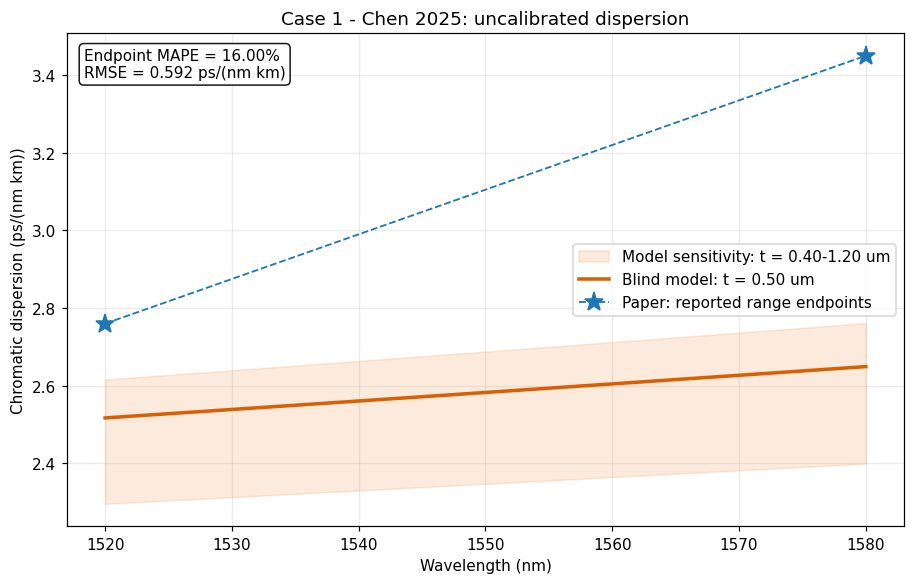

In [3]:
case1_wavelength_nm = np.arange(1520.0, 1580.1, 1.0)
case1_paper_wavelength_nm = np.array([1520.0, 1580.0])
case1_paper_d = np.array([2.76, 3.45])
case1_wall_grid_um = np.array([0.40, 0.50, 0.60, 0.80, 1.00, 1.20])

case1_curves = []
for wall_um in case1_wall_grid_um:
    geometry = DNANFGeometry(
        core_radius_um=33.2 / 2.0,
        membrane_thickness_um=wall_um,
        outer_tube_diameter_um=37.7,
        tube_count=5,
        nesting_order=1,
    )
    case1_curves.append(
        chromatic_dispersion_ps_nm_km(case1_wavelength_nm * 1e-9, geometry)
    )
case1_curves = np.asarray(case1_curves)
case1_nominal_curve = case1_curves[1]
case1_model_at_paper = np.interp(
    case1_paper_wavelength_nm, case1_wavelength_nm, case1_nominal_curve
)
case1_error = relative_error_percent(case1_model_at_paper, case1_paper_d)
case1_rmse = rmse(case1_model_at_paper, case1_paper_d)
case1_mape = mape(case1_model_at_paper, case1_paper_d)

case1_table = pd.DataFrame({
    "Wavelength (nm)": case1_paper_wavelength_nm,
    "Paper measured D": case1_paper_d,
    "Model D (t=0.50 um)": case1_model_at_paper,
    "Relative error (%)": case1_error,
    "Data provenance": ["text-reported endpoint"] * 2,
})
show_table(case1_table.round(4), "Case 1 point-by-point error")
print(f"RMSE = {case1_rmse:.4f} ps/(nm km)")
print(f"MAPE = {case1_mape:.3f}%")
print("Scope: conditional geometry validation; membrane thickness is not disclosed.")

fig, ax = plt.subplots(figsize=(8.2, 5.2), constrained_layout=True)
ax.fill_between(
    case1_wavelength_nm,
    case1_curves.min(axis=0),
    case1_curves.max(axis=0),
    color="#f4a261",
    alpha=0.22,
    label="Model sensitivity: t = 0.40-1.20 um",
)
ax.plot(
    case1_wavelength_nm,
    case1_nominal_curve,
    color="#d95f02",
    lw=2.3,
    label="Blind model: t = 0.50 um",
)
ax.plot(
    case1_paper_wavelength_nm,
    case1_paper_d,
    color="#1f77b4",
    ls="--",
    lw=1.2,
    marker="*",
    ms=13,
    label="Paper: reported range endpoints",
)
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Chromatic dispersion (ps/(nm km))")
ax.set_title("Case 1 - Chen 2025: uncalibrated dispersion")
ax.legend()
ax.text(
    0.02, 0.97,
    f"Endpoint MAPE = {case1_mape:.2f}%\nRMSE = {case1_rmse:.3f} ps/(nm km)",
    transform=ax.transAxes, va="top",
    bbox={"boxstyle": "round", "fc": "white", "alpha": 0.9},
)
fig.savefig("case1_chen_dispersion.png", bbox_inches="tight")
plt.show()


## Case 2 - Ge et al. OFC 2023: 고정 gamma 검증

발표자료의 실험조건은 총 HCF 길이 466+526 m, core diameter 32.5 um, tube thickness 1.2 um, (A_{eff}=572\,\mu m^2), 1550 nm, 실제 launch power 37 dBm입니다. 실험에서 직접적인 비선형 위상천이는 관측되지 않았고 (n_{2,Kerr}<2.20\times10^{-23}\,m^2/W)의 상한을 제시합니다.

상한값은 등식 측정값이 아니므로 MAPE 대신 현재 코드의 gamma가 실험 상한을 몇 배 초과하는지 계산합니다.



Case 2 upper-bound test
            Quantity       Paper Current code                Comparison Result
    gamma [1/(W km)] < 1.559e-04    5.000e-04       3.207 x upper bound   FAIL
equivalent n2 [m2/W] < 2.200e-23    7.055e-23 +220.7% above upper bound   FAIL


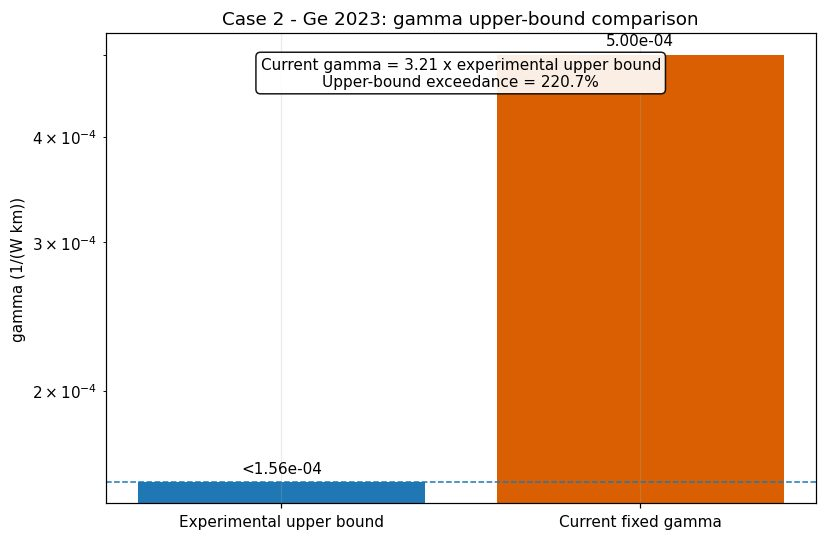

In [4]:
case2_lambda_m = 1550e-9
case2_aeff_m2 = 572e-12
case2_n2_upper = 2.20e-23
case2_gamma_upper = (
    2.0 * np.pi * case2_n2_upper / (case2_lambda_m * case2_aeff_m2) * 1000.0
)
case2_n2_equivalent = (
    (CURRENT_GAMMA_PER_W_KM / 1000.0)
    * case2_lambda_m * case2_aeff_m2 / (2.0 * np.pi)
)
case2_ratio = CURRENT_GAMMA_PER_W_KM / case2_gamma_upper
case2_exceed_percent = 100.0 * (case2_ratio - 1.0)
case2_pass = CURRENT_GAMMA_PER_W_KM <= case2_gamma_upper

case2_table = pd.DataFrame([
    {
        "Quantity": "gamma [1/(W km)]",
        "Paper": f"< {case2_gamma_upper:.3e}",
        "Current code": f"{CURRENT_GAMMA_PER_W_KM:.3e}",
        "Comparison": f"{case2_ratio:.3f} x upper bound",
        "Result": "PASS" if case2_pass else "FAIL",
    },
    {
        "Quantity": "equivalent n2 [m2/W]",
        "Paper": f"< {case2_n2_upper:.3e}",
        "Current code": f"{case2_n2_equivalent:.3e}",
        "Comparison": f"+{case2_exceed_percent:.1f}% above upper bound",
        "Result": "PASS" if case2_pass else "FAIL",
    },
])
show_table(case2_table, "Case 2 upper-bound test")

fig, ax = plt.subplots(figsize=(7.4, 4.8), constrained_layout=True)
bars = ax.bar(
    ["Experimental upper bound", "Current fixed gamma"],
    [case2_gamma_upper, CURRENT_GAMMA_PER_W_KM],
    color=["#1f77b4", "#d95f02"],
)
ax.set_yscale("log")
ax.set_ylabel("gamma (1/(W km))")
ax.set_title("Case 2 - Ge 2023: gamma upper-bound comparison")
ax.axhline(case2_gamma_upper, color="#1f77b4", ls="--", lw=1.0)
ax.bar_label(bars, labels=[f"<{case2_gamma_upper:.2e}", f"{CURRENT_GAMMA_PER_W_KM:.2e}"], padding=4)
ax.text(
    0.5, 0.95,
    f"Current gamma = {case2_ratio:.2f} x experimental upper bound\n"
    f"Upper-bound exceedance = {case2_exceed_percent:.1f}%",
    transform=ax.transAxes, ha="center", va="top",
    bbox={"boxstyle": "round", "fc": "white", "alpha": 0.9},
)
fig.savefig("case2_ge_kerr_bound.png", bbox_inches="tight")
plt.show()


## Case 3 - Hong et al. 2024/2025: launch power → AIR

실험은 1.085-km HCF와 약 45.6-km buffering SMF로 구성된 recirculating loop를 사용하고, 130-GBaud PCS-64QAM CUT + 8개 인접채널을 전송했습니다. 25 loops, 총 launch power 23 dBm(약 13.5 dBm/channel)에서 HCF AIR은 약 1.08 Tb/s이며, HCF에서 식별 가능한 비선형 페널티가 없었습니다.

이 HCF는 DNANF가 아니라 photonic-bandgap 계열이며 실험에서 VOA로 일정 OSNR을 유지했습니다. 따라서 아래 AIR 오차는 기존 코드의 NF/TRX 가정을 적용한 **조건부 시스템 비교**입니다. 기하모델 검증으로 해석하면 안 됩니다.



Case 3 anchor comparison
 Total launch (dBm)  Pch (dBm)  Paper AIR (Tb/s)  Raw model AIR (Tb/s)  AIR error (%)  Predicted NLI penalty (dB)
               23.0  13.457575              1.08              1.725227      59.743244                    0.000005
Observed HCF nonlinearity: no discernible penalty up to 23 dBm total.
Model NLI penalty at 23 dBm: 4.762e-06 dB -> qualitative PASS
Absolute AIR: CONDITIONAL because buffering-SMF/VOA OSNR and measured TRX SNR are not modeled.


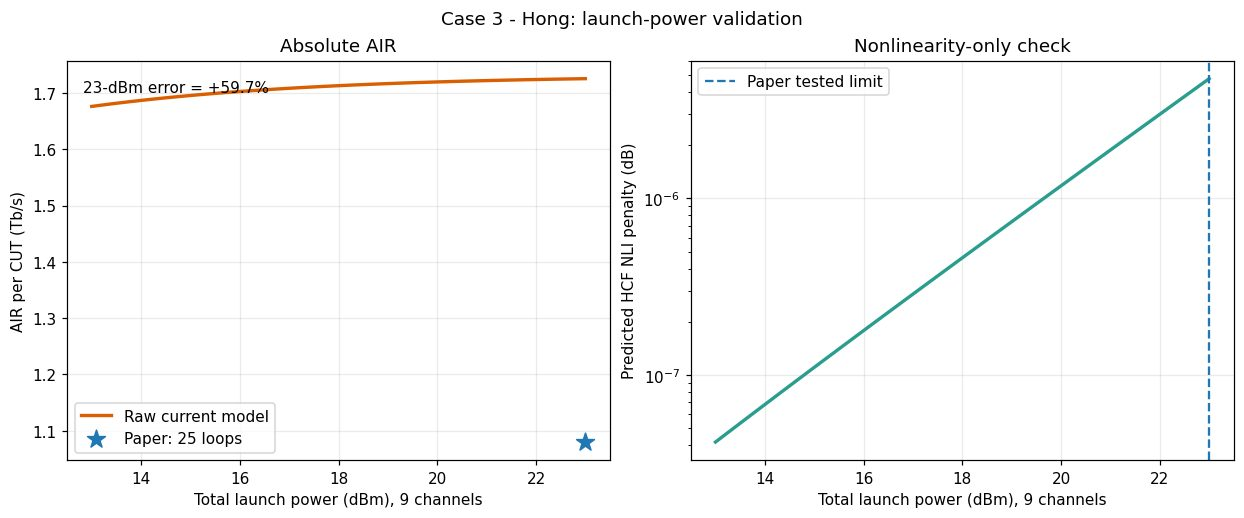

In [5]:
case3_total_launch_dbm = np.arange(13.0, 23.01, 0.25)
case3_n_channels = 9
case3_symbol_rate_hz = 130e9
case3_spacing_hz = 150e9
case3_fiber_length_km = 1.085
case3_loops = 25
case3_insertion_loss_db_per_loop = 5.7
case3_alpha_equivalent = case3_insertion_loss_db_per_loop / case3_fiber_length_km
case3_lambda_m = 1559.39e-9
case3_assumed_d = 3.2
case3_pch_dbm = case3_total_launch_dbm - 10.0 * np.log10(case3_n_channels)

case3_eta = closed_form_gn_eta(
    case3_lambda_m, case3_assumed_d, case3_alpha_equivalent,
    case3_symbol_rate_hz, case3_spacing_hz, case3_n_channels,
    n_spans=case3_loops,
)
case3_ase = ase_from_amplifier_losses_w(
    C0 / case3_lambda_m,
    case3_symbol_rate_hz,
    [case3_insertion_loss_db_per_loop],
    repetitions=case3_loops,
)
case3_result = raw_shannon_throughput_tbps(
    case3_pch_dbm,
    1,
    case3_symbol_rate_hz,
    case3_ase,
    case3_eta,
    case3_fiber_length_km * case3_loops,
    imi_db_per_km=None,
)
case3_snr_no_nli = case3_result["power_w"] / (
    case3_result["ase_w"] + case3_result["trx_w"]
)
case3_nli_penalty_db = 10.0 * np.log10(
    case3_snr_no_nli / case3_result["snr_linear"]
)

case3_paper_total_launch_dbm = 23.0
case3_paper_air_tbps = 1.08
case3_model_air_tbps = float(case3_result["throughput_tbps"][-1])
case3_air_error_percent = float(
    relative_error_percent(case3_model_air_tbps, case3_paper_air_tbps)
)
case3_max_nli_penalty_db = float(case3_nli_penalty_db[-1])

case3_table = pd.DataFrame([{
    "Total launch (dBm)": case3_paper_total_launch_dbm,
    "Pch (dBm)": case3_pch_dbm[-1],
    "Paper AIR (Tb/s)": case3_paper_air_tbps,
    "Raw model AIR (Tb/s)": case3_model_air_tbps,
    "AIR error (%)": case3_air_error_percent,
    "Predicted NLI penalty (dB)": case3_max_nli_penalty_db,
}])
show_table(case3_table.round(6), "Case 3 anchor comparison")
print("Observed HCF nonlinearity: no discernible penalty up to 23 dBm total.")
print(f"Model NLI penalty at 23 dBm: {case3_max_nli_penalty_db:.3e} dB -> qualitative PASS")
print("Absolute AIR: CONDITIONAL because buffering-SMF/VOA OSNR and measured TRX SNR are not modeled.")

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.6), constrained_layout=True)
axes[0].plot(case3_total_launch_dbm, case3_result["throughput_tbps"], color="#d95f02", lw=2.2, label="Raw current model")
axes[0].scatter([23.0], [case3_paper_air_tbps], marker="*", s=150, color="#1f77b4", label="Paper: 25 loops")
axes[0].set_xlabel("Total launch power (dBm), 9 channels")
axes[0].set_ylabel("AIR per CUT (Tb/s)")
axes[0].set_title("Absolute AIR")
axes[0].legend()
axes[0].text(0.03, 0.95, f"23-dBm error = {case3_air_error_percent:+.1f}%", transform=axes[0].transAxes, va="top")

axes[1].semilogy(case3_total_launch_dbm, np.maximum(case3_nli_penalty_db, 1e-10), color="#2a9d8f", lw=2.2)
axes[1].axvline(23.0, color="#1f77b4", ls="--", label="Paper tested limit")
axes[1].set_xlabel("Total launch power (dBm), 9 channels")
axes[1].set_ylabel("Predicted HCF NLI penalty (dB)")
axes[1].set_title("Nonlinearity-only check")
axes[1].legend()
fig.suptitle("Case 3 - Hong: launch-power validation")
fig.savefig("case3_hong_launch_air.png", bbox_inches="tight")
plt.show()


## Case 4 - Ge et al. 2025: IMI → 1-Tb/s reach

논문의 저-IMI DNANF-5 링크는 54.8395 + 91.9314 km, IMI -74 dB/km이며 73 loops(10,714.28 km)에서 1.00115 Tb/s를 달성했습니다. 고-IMI 링크는 30.8037 + 68.1653 km, IMI -64 dB/km이며 약 3,459.8 km에서 1.0138 Tb/s를 달성했습니다.

정확한 EDFA NF와 back-to-back TRX SNR이 공개되지 않았으므로 현재 코드의 5 dB/20 dB를 사용합니다. 저-IMI 링크에는 논문이 제시한 0.144/0.134 dB/km를 사용하고, 고-IMI 링크는 `similar attenuation`만 공개되어 0.15 dB/km를 가정합니다.



Case 4 reach-anchor error
    Link  IMI (dB/km)  Paper distance (km)  Paper rate (Tb/s)  Raw model rate (Tb/s)  Rate error (%)
 low IMI        -74.0             10714.28            1.00115                1.66945        66.75292
high IMI        -64.0              3459.80            1.01380                1.65161        62.91267
RMSE = 0.6532 Tb/s; MAPE = 64.833%
Interpretation: raw Shannon throughput overestimates modulation-constrained measured rate.


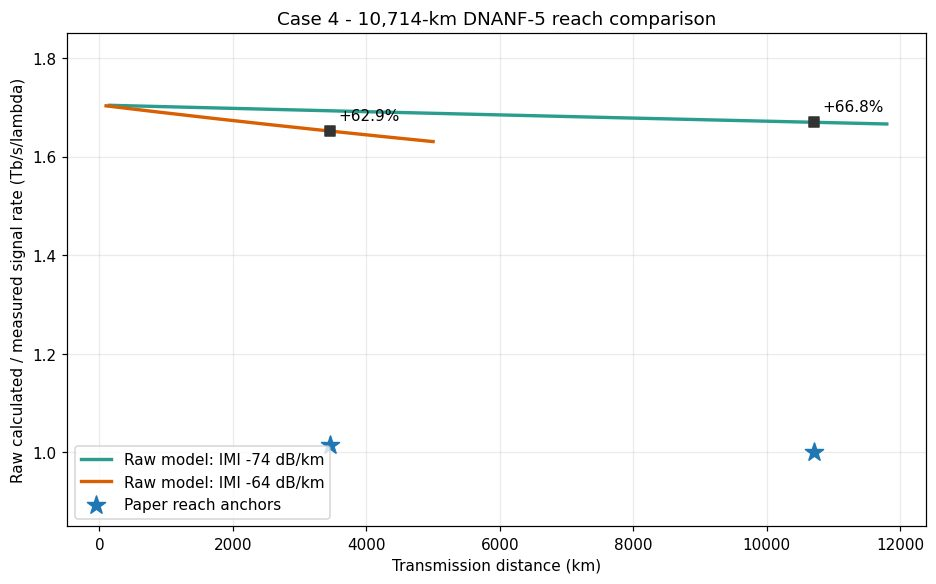

In [6]:
def case4_rate_at_distance(
    distance_km,
    loop_lengths_km,
    span_alphas_db_km,
    imi_db_km,
    frequency_hz,
):
    loop_length = float(np.sum(loop_lengths_km))
    loops = np.asarray(distance_km, dtype=float) / loop_length
    rate_hz = 128e9
    wavelength_m = C0 / frequency_hz
    span_losses = np.asarray(loop_lengths_km) * np.asarray(span_alphas_db_km)
    ase = np.asarray([
        ase_from_amplifier_losses_w(
            frequency_hz, rate_hz, span_losses, repetitions=float(rep)
        )
        for rep in np.atleast_1d(loops)
    ])
    average_alpha = float(
        np.sum(np.asarray(loop_lengths_km) * np.asarray(span_alphas_db_km))
        / loop_length
    )
    eta = closed_form_gn_eta(
        wavelength_m, 3.62, average_alpha, rate_hz, 150e9, 1,
        n_spans=2.0 * loops,
    )
    result = raw_shannon_throughput_tbps(
        23.0, 1, rate_hz, ase, eta, np.asarray(distance_km), imi_db_km
    )
    return np.asarray(result["throughput_tbps"], dtype=float)


case4_low_distance = np.linspace(146.77, 11_800.0, 220)
case4_high_distance = np.linspace(98.969, 5_000.0, 180)
case4_low_curve = case4_rate_at_distance(
    case4_low_distance,
    [54.8395, 91.9314],
    [0.144, 0.134],
    -74.0,
    192.475e12,
)
case4_high_curve = case4_rate_at_distance(
    case4_high_distance,
    [30.8037, 68.1653],
    [0.15, 0.15],
    -64.0,
    192.55e12,
)

case4_paper_distance = np.array([10_714.28, 3_459.8])
case4_paper_rate = np.array([1.00115, 1.0138])
case4_model_rate = np.array([
    case4_rate_at_distance(
        [case4_paper_distance[0]], [54.8395, 91.9314],
        [0.144, 0.134], -74.0, 192.475e12
    )[0],
    case4_rate_at_distance(
        [case4_paper_distance[1]], [30.8037, 68.1653],
        [0.15, 0.15], -64.0, 192.55e12
    )[0],
])
case4_error = relative_error_percent(case4_model_rate, case4_paper_rate)
case4_mape = mape(case4_model_rate, case4_paper_rate)
case4_rmse = rmse(case4_model_rate, case4_paper_rate)

case4_table = pd.DataFrame({
    "Link": ["low IMI", "high IMI"],
    "IMI (dB/km)": [-74.0, -64.0],
    "Paper distance (km)": case4_paper_distance,
    "Paper rate (Tb/s)": case4_paper_rate,
    "Raw model rate (Tb/s)": case4_model_rate,
    "Rate error (%)": case4_error,
})
show_table(case4_table.round(5), "Case 4 reach-anchor error")
print(f"RMSE = {case4_rmse:.4f} Tb/s; MAPE = {case4_mape:.3f}%")
print("Interpretation: raw Shannon throughput overestimates modulation-constrained measured rate.")

fig, ax = plt.subplots(figsize=(8.4, 5.2), constrained_layout=True)
ax.plot(case4_low_distance, case4_low_curve, color="#2a9d8f", lw=2.2, label="Raw model: IMI -74 dB/km")
ax.plot(case4_high_distance, case4_high_curve, color="#d95f02", lw=2.2, label="Raw model: IMI -64 dB/km")
ax.scatter(case4_paper_distance, case4_paper_rate, marker="*", s=155, color="#1f77b4", label="Paper reach anchors", zorder=5)
for x, y, e in zip(case4_paper_distance, case4_model_rate, case4_error):
    ax.scatter([x], [y], marker="s", s=42, color="#333333", zorder=5)
    ax.annotate(f"{e:+.1f}%", (x, y), xytext=(5, 7), textcoords="offset points")
ax.set_xlabel("Transmission distance (km)")
ax.set_ylabel("Raw calculated / measured signal rate (Tb/s/lambda)")
ax.set_title("Case 4 - 10,714-km DNANF-5 reach comparison")
ax.set_ylim(0.85, 1.85)
ax.legend()
fig.savefig("case4_ge_10714km_reach.png", bbox_inches="tight")
plt.show()


## Case 5 - Ali et al. OFC 2025: unrepeated 거리 → throughput

논문은 32개 real-time transceiver, 최대 138 GBaud PS-16QAM, 150-GHz spacing을 사용했습니다. 102.3-200.5 km에서 32x800 Gb/s = 25.6 Tb/s, 250 km에서 10.1 Tb/s, 301.7 km에서 2채널 합계 0.5 Tb/s를 보고했습니다. 200.5-km 링크 IMI는 -60 dB/km입니다.

현재 코드의 Shannon 식은 실제 transceiver modulation/FEC rate ceiling이 없습니다. 따라서 이 Case는 현재 코드가 실제 장비 throughput을 얼마나 과대평가하는지 확인합니다. 301.7-km 손실은 `>70 dB`이므로 보수적으로 70 dB를 사용합니다.



Case 5 distance-throughput error
 Distance (km)  Link loss used (dB)  Channels  Pch used (dBm)  Paper throughput (Tb/s)  Raw model throughput (Tb/s)  Model SNR (dB)  Error (%)
         102.3              23.4703        32         18.9485                     25.6                      58.4812         19.8884   128.4422
         200.5              46.0000        32         18.9485                     25.6                      41.9624         14.1381    63.9155
         250.0              57.0000        32         21.9485                     10.1                      23.4215          7.2304   131.8960
         301.7              70.0000         2         34.0000                      0.5                       1.3267          6.3251   165.3353
RMSE = 19.5387 Tb/s; MAPE = 122.397%
Scope: conditional system test; baud/modulation/FEC settings change at long distances.


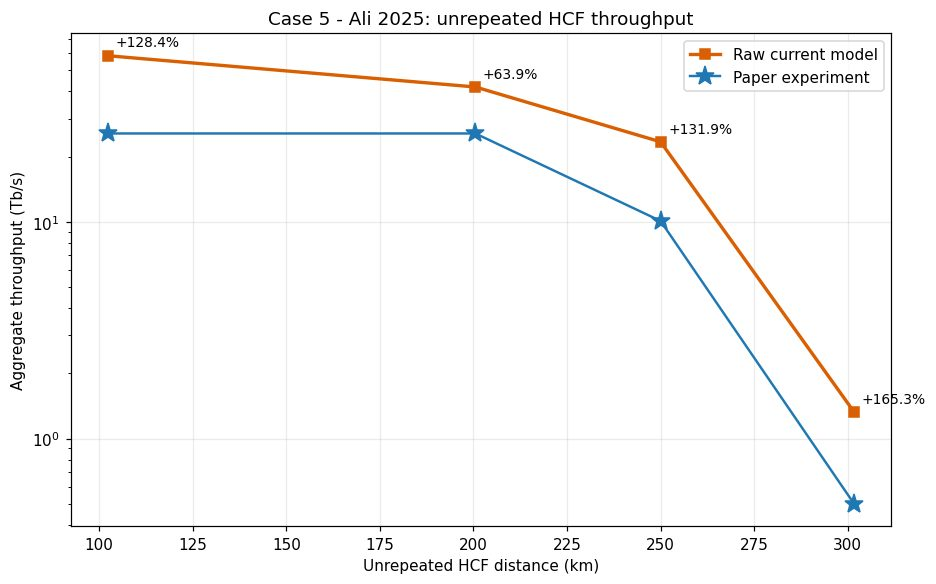

In [7]:
case5_distance_km = np.array([102.3, 200.5, 250.0, 301.7])
case5_loss_db = np.array([46.0 / 200.5 * 102.3, 46.0, 57.0, 70.0])
case5_n_channels = np.array([32, 32, 32, 2])
case5_paper_rate_tbps = np.array([25.6, 25.6, 10.1, 0.5])
case5_total_launch_dbm = np.array([34.0, 34.0, 37.0, np.nan])
case5_pch_dbm = np.array([
    34.0 - 10.0 * np.log10(32),
    34.0 - 10.0 * np.log10(32),
    37.0 - 10.0 * np.log10(32),
    34.0,  # paper: each of two neighbouring channels launched at 34 dBm
])

case5_model_rate = []
case5_model_snr_db = []
for distance, loss, nch, pch in zip(
    case5_distance_km, case5_loss_db, case5_n_channels, case5_pch_dbm
):
    alpha = loss / distance
    lambda_m = 1550e-9
    eta = closed_form_gn_eta(
        lambda_m, 3.9, alpha, 138e9, 150e9, int(nch), n_spans=1.0
    )
    ase = ase_from_amplifier_losses_w(
        C0 / lambda_m, 138e9, [loss], repetitions=1.0
    )
    out = raw_shannon_throughput_tbps(
        pch, int(nch), 138e9, ase, eta, distance, -60.0
    )
    case5_model_rate.append(float(out["throughput_tbps"]))
    case5_model_snr_db.append(float(10.0 * np.log10(out["snr_linear"])))

case5_model_rate = np.asarray(case5_model_rate)
case5_model_snr_db = np.asarray(case5_model_snr_db)
case5_error = relative_error_percent(case5_model_rate, case5_paper_rate_tbps)
case5_mape = mape(case5_model_rate, case5_paper_rate_tbps)
case5_rmse = rmse(case5_model_rate, case5_paper_rate_tbps)

case5_table = pd.DataFrame({
    "Distance (km)": case5_distance_km,
    "Link loss used (dB)": case5_loss_db,
    "Channels": case5_n_channels,
    "Pch used (dBm)": case5_pch_dbm,
    "Paper throughput (Tb/s)": case5_paper_rate_tbps,
    "Raw model throughput (Tb/s)": case5_model_rate,
    "Model SNR (dB)": case5_model_snr_db,
    "Error (%)": case5_error,
})
show_table(case5_table.round(4), "Case 5 distance-throughput error")
print(f"RMSE = {case5_rmse:.4f} Tb/s; MAPE = {case5_mape:.3f}%")
print("Scope: conditional system test; baud/modulation/FEC settings change at long distances.")

fig, ax = plt.subplots(figsize=(8.4, 5.2), constrained_layout=True)
ax.plot(case5_distance_km, case5_model_rate, color="#d95f02", marker="s", lw=2.2, label="Raw current model")
ax.plot(case5_distance_km, case5_paper_rate_tbps, color="#1f77b4", marker="*", ms=13, lw=1.6, label="Paper experiment")
for x, y, e in zip(case5_distance_km, case5_model_rate, case5_error):
    ax.annotate(f"{e:+.1f}%", (x, y), xytext=(5, 6), textcoords="offset points", fontsize=9)
ax.set_yscale("log")
ax.set_xlabel("Unrepeated HCF distance (km)")
ax.set_ylabel("Aggregate throughput (Tb/s)")
ax.set_title("Case 5 - Ali 2025: unrepeated HCF throughput")
ax.legend()
fig.savefig("case5_ali_unrepeated_throughput.png", bbox_inches="tight")
plt.show()


## 종합 결과

서로 다른 물리량과 상한값을 하나의 평균 MAPE로 합치지 않습니다. 아래 표에서 Case별 오차와 검증 범위를 따로 확인합니다.


In [8]:
summary = pd.DataFrame([
    {
        "Case": "1 Chen 2025",
        "Validated layer": "Geometry -> dispersion",
        "Metric": "D endpoints",
        "RMSE": f"{case1_rmse:.4f} ps/(nm km)",
        "Error indicator": f"MAPE {case1_mape:.2f}%",
        "Assessment": "CONDITIONAL",
        "Main limitation": "Membrane thickness undisclosed; t=0.50 um used",
    },
    {
        "Case": "2 Ge OFC 2023",
        "Validated layer": "Fixed gamma / Kerr",
        "Metric": "Experimental upper bound",
        "RMSE": "N/A",
        "Error indicator": f"{case2_ratio:.2f}x; +{case2_exceed_percent:.1f}% above bound",
        "Assessment": "FAIL",
        "Main limitation": "Paper reports an upper limit, not equality",
    },
    {
        "Case": "3 Hong 2024/25",
        "Validated layer": "Launch power -> AIR/NLI",
        "Metric": "AIR at 23 dBm total",
        "RMSE": f"{abs(case3_model_air_tbps-case3_paper_air_tbps):.4f} Tb/s (1 point)",
        "Error indicator": f"AIR {case3_air_error_percent:+.2f}%; NLI qualitative PASS",
        "Assessment": "PARTIAL",
        "Main limitation": "PBG-HCF hybrid loop; controlled OSNR not reproduced",
    },
    {
        "Case": "4 Ge 10714 km",
        "Validated layer": "IMI/ASE -> raw reach rate",
        "Metric": "Two reach anchors",
        "RMSE": f"{case4_rmse:.4f} Tb/s",
        "Error indicator": f"MAPE {case4_mape:.2f}%",
        "Assessment": "CONDITIONAL FAIL",
        "Main limitation": "NF/TRX assumed; modulation/GMI ceiling absent",
    },
    {
        "Case": "5 Ali 301.7 km",
        "Validated layer": "Unrepeated system throughput",
        "Metric": "Four distance anchors",
        "RMSE": f"{case5_rmse:.4f} Tb/s",
        "Error indicator": f"MAPE {case5_mape:.2f}%",
        "Assessment": "CONDITIONAL FAIL",
        "Main limitation": "Adaptive modulation/FEC and amplifier details absent",
    },
])
show_table(summary, "Independent five-paper validation summary")
summary.to_csv("independent_hcf_5paper_summary.csv", index=False)
case1_table.to_csv("case1_chen_dispersion_errors.csv", index=False)
case2_table.to_csv("case2_ge_kerr_bound.csv", index=False)
case3_table.to_csv("case3_hong_air_error.csv", index=False)
case4_table.to_csv("case4_ge_10714km_errors.csv", index=False)
case5_table.to_csv("case5_ali_unrepeated_errors.csv", index=False)

# Reproducibility guards: fail loudly if a later edit breaks the numerical run.
assert np.isfinite(case1_mape) and 0.0 <= case1_mape < 100.0
assert CURRENT_GAMMA_PER_W_KM > case2_gamma_upper
assert case3_max_nli_penalty_db < 0.01
assert np.isfinite(case4_mape) and np.isfinite(case5_mape)
assert len(summary) == 5 and not summary.isna().any().any()

print("\n=== Evidence-based conclusion ===")
print("1) Uncalibrated dispersion has a conditional endpoint MAPE of " f"{case1_mape:.2f}% for Chen's 5-capillary sample.")
print("2) The current fixed gamma exceeds Ge's experimental upper bound by " f"{case2_exceed_percent:.1f}%.")
print("3) The model correctly predicts negligible HCF NLI in Hong's tested power range, but absolute AIR is overestimated because measured loop OSNR/hardware limits are absent.")
print("4) The 10,714-km and unrepeated-link rates are strongly overestimated by the uncapped Shannon formula.")
print("5) Therefore the existing low error against the Sohanpal Fig. 2/3 reproduction does not transfer to independent experiments without Aeff-derived gamma, measured hardware noise, IMI validation, and modulation/FEC constraints.")
print("\nCSV and PNG result files have been written to the current Colab directory.")



Independent five-paper validation summary
          Case              Validated layer                   Metric                  RMSE                   Error indicator       Assessment                                      Main limitation
   1 Chen 2025       Geometry -> dispersion              D endpoints     0.5917 ps/(nm km)                       MAPE 16.00%      CONDITIONAL       Membrane thickness undisclosed; t=0.50 um used
 2 Ge OFC 2023           Fixed gamma / Kerr Experimental upper bound                   N/A        3.21x; +220.7% above bound             FAIL           Paper reports an upper limit, not equality
3 Hong 2024/25      Launch power -> AIR/NLI      AIR at 23 dBm total 0.6452 Tb/s (1 point) AIR +59.74%; NLI qualitative PASS          PARTIAL  PBG-HCF hybrid loop; controlled OSNR not reproduced
 4 Ge 10714 km    IMI/ASE -> raw reach rate        Two reach anchors           0.6532 Tb/s                       MAPE 64.83% CONDITIONAL FAIL        NF/TRX assumed; modulation/G